In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEQUENCE_FILE = Path("../data/processed/all_emotions.csv")
LABEL_FILE = Path("../data/processed/video_emotion_stats.csv")
METADATA_FILE = Path("../data/raw/metadata.csv")

all_emotions = pd.read_csv(SEQUENCE_FILE)
label_df = pd.read_csv(LABEL_FILE)
metadata_df = pd.read_csv(METADATA_FILE)

In [4]:
all_emotions.columns

Index(['start', 'end', 'text', 'time', 'admiration', 'amusement', 'anger',
       'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral', 'video_id'],
      dtype='object')

In [6]:
label_df.columns

Index(['video_id', 'admiration_mean', 'admiration_std', 'admiration_max',
       'amusement_mean', 'amusement_std', 'amusement_max', 'anger_mean',
       'anger_std', 'anger_max', 'annoyance_mean', 'annoyance_std',
       'annoyance_max', 'approval_mean', 'approval_std', 'approval_max',
       'caring_mean', 'caring_std', 'caring_max', 'confusion_mean',
       'confusion_std', 'confusion_max', 'curiosity_mean', 'curiosity_std',
       'curiosity_max', 'desire_mean', 'desire_std', 'desire_max',
       'disappointment_mean', 'disappointment_std', 'disappointment_max',
       'disapproval_mean', 'disapproval_std', 'disapproval_max',
       'disgust_mean', 'disgust_std', 'disgust_max', 'embarrassment_mean',
       'embarrassment_std', 'embarrassment_max', 'excitement_mean',
       'excitement_std', 'excitement_max', 'fear_mean', 'fear_std', 'fear_max',
       'gratitude_mean', 'gratitude_std', 'gratitude_max', 'grief_mean',
       'grief_std', 'grief_max', 'joy_mean', 'joy_std', 'joy_max',

In [57]:
metadata_df.columns

Index(['video_id', 'videoUrl', 'title', 'publishDate', 'channelTitle',
       'channelId', 'tags', 'categoryId', 'liveBroadcastContent',
       'defaultAudioLanguage', 'duration_sec', 'viewCount', 'likeCount',
       'commentCount', 'channelViewCount', 'subscriberCount',
       'hiddenSubscriberCount', 'channelVideoCount'],
      dtype='object')

In [10]:
columns_from_metadata = ['videoId', 'videoUrl', 'title', 'publishDate', 'channelTitle', 'tags',
                         'duration_sec', 'viewCount', 'likeCount', 'commentCount', 'channelViewCount', 'subscriberCount', 'channelVideoCount']
new_label_df = metadata_df[columns_from_metadata]

In [12]:
video_counts = all_emotions['video_id'].value_counts()
print(video_counts)

video_id
FFjGn-fRVLs    416
4dOgWZsDB6Q    403
9l54NfLvAOQ    388
KDmEUA7DEOs    381
ceV3RsG946s    357
              ... 
ftmY4ceOFtw      1
idNCWRKMj0k      1
mg1ZqahIpVw      1
o6bwVG8qjCQ      1
OKBMgYOuVNg      1
Name: count, Length: 26180, dtype: int64


In [13]:
print(type(video_counts))

<class 'pandas.core.series.Series'>


(array([5.1100e+02, 1.3389e+04, 8.0780e+03, 3.0170e+03, 7.7700e+02,
        2.8500e+02, 8.6000e+01, 2.3000e+01, 1.0000e+01, 4.0000e+00]),
 array([  1. ,  42.5,  84. , 125.5, 167. , 208.5, 250. , 291.5, 333. ,
        374.5, 416. ]),
 <BarContainer object of 10 artists>)

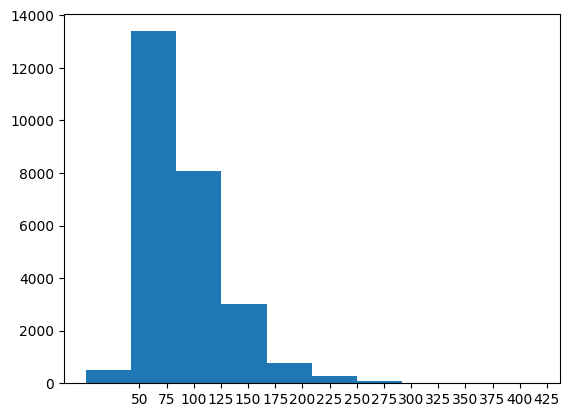

In [41]:
ticks = range(50, 450, 25)
plt.xticks(
    ticks=ticks,
)
plt.hist(video_counts)

In [52]:
len(video_counts[video_counts<42])

188

In [42]:
print(video_counts.quantile(0.75))
print(video_counts.quantile(0.5))

109.0
81.0


In [67]:
def resize_list_with_interpolation(original_list, target_size=100):
    """
    Resizes a list to a fixed target_size using linear interpolation.

    Args:
        original_list (list): The input list of numerical values.
        target_size (int): The desired fixed size of the output list.

    Returns:
        list: A new list of the target_size with interpolated values.
    """

    original_indices = np.linspace(0, len(original_list) - 1, num=len(original_list))
    target_indices = np.linspace(0, len(original_list) - 1, num=target_size)

    interpolated_values = np.interp(target_indices, original_indices, original_list)
    return interpolated_values.tolist()

In [58]:
unique_video_ids = metadata_df['video_id'].unique()
video_ids_to_remove = []

In [70]:
EMOTION_COLUMNS = [col for col in all_emotions.columns if col not in ['start', 'end', 'text', 'time', 'video_id']]

In [64]:
from tqdm import tqdm

In [73]:
all_emotions_consolidated = []
for video_id in tqdm(unique_video_ids):
    emotions_df = all_emotions[all_emotions['video_id'] == video_id]
    if len(emotions_df) < 42:
        video_ids_to_remove.append(video_id)
        continue
    
    data = {"video_id": video_id,
            **{ emotion: resize_list_with_interpolation(emotions_df[emotion].values)
               for emotion in EMOTION_COLUMNS
               }
            }
    
    # data = {
    #     "video_id": video_id,
    #     'admiration': resize_list_with_interpolation(emotions_df['admiration'].values),
    #     'amusement': resize_list_with_interpolation(emotions_df['amusement'].values),
    #     'anger': resize_list_with_interpolation(emotions_df['anger'].values),
    #     'annoyance': resize_list_with_interpolation(emotions_df['annoyance'].values),
    #     'approval': resize_list_with_interpolation(emotions_df['approval'].values),
    #     'caring': resize_list_with_interpolation(emotions_df['caring'].values),
    #     'confusion': resize_list_with_interpolation(emotions_df['confusion'].values),
    #     'curiosity': resize_list_with_interpolation(emotions_df['curiosity'].values),
    #     'desire': resize_list_with_interpolation(emotions_df['desire'].values),
    #     'disappointment': resize_list_with_interpolation(emotions_df['disappointment'].values),
    #     'disapproval': resize_list_with_interpolation(emotions_df['disapproval'].values),
    #     'disgust': resize_list_with_interpolation(emotions_df['disgust'].values),
    #     'embarrassment': resize_list_with_interpolation(emotions_df['embarrassment'].values),
    #     'excitement': resize_list_with_interpolation(emotions_df['excitement'].values),
    #     'fear': resize_list_with_interpolation(emotions_df['fear'].values),
    #     'gratitude': resize_list_with_interpolation(emotions_df['gratitude'].values),
    #     'grief': resize_list_with_interpolation(emotions_df['grief'].values),
    #     'joy': resize_list_with_interpolation(emotions_df['joy'].values),
    #     'love': resize_list_with_interpolation(emotions_df['love'].values),
    #     'nervousness': resize_list_with_interpolation(emotions_df['nervousness'].values),
    #     'optimism': resize_list_with_interpolation(emotions_df['optimism'].values),
    #     'pride': resize_list_with_interpolation(emotions_df['pride'].values),
    #     'realization': resize_list_with_interpolation(emotions_df['realization'].values),
    #     'relief': resize_list_with_interpolation(emotions_df['relief'].values),
    #     'remorse': resize_list_with_interpolation(emotions_df['remorse'].values),
    #     'sadness': resize_list_with_interpolation(emotions_df['sadness'].values),
    #     'surprise': resize_list_with_interpolation(emotions_df['surprise'].values),
    #     'neutral': resize_list_with_interpolation(emotions_df['neutral'].values)
    # }
    
    all_emotions_consolidated.append(data)
    
all_emotions_consolidated_df = pd.DataFrame(all_emotions_consolidated)

100%|██████████| 26180/26180 [37:26<00:00, 11.66it/s]


In [75]:
print(len(video_ids_to_remove))

188


In [74]:
all_emotions_consolidated_df

,video_id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,wL8qX260NTk,"[0.7320703268051147, 0.5988654000590545, 0.468...","[0.3544187843799591, 0.26652273475521737, 0.18...","[0.165129467844963, 0.1971059975901035, 0.2280...","[0.3012798130512237, 0.4159526021191568, 0.525...","[0.6537723541259766, 0.6795488945161453, 0.703...","[0.7575482130050659, 0.7378989096843835, 0.719...","[0.6837587356567383, 0.7505427598953247, 0.814...","[0.722643256187439, 0.7603157397472498, 0.7978...","[0.6324456334114075, 0.5751241174611178, 0.518...",...,"[0.510483980178833, 0.3411469661226176, 0.1769...","[0.3000362515449524, 0.3093896201162627, 0.319...","[0.3813637495040893, 0.3087617700750177, 0.239...","[0.486762672662735, 0.4345286088158386, 0.3829...","[0.6520442962646484, 0.6714753803580699, 0.689...","[0.5506535172462463, 0.4248895831782408, 0.303...","[0.6306228041648865, 0.6180141941465512, 0.604...","[0.2179347872734069, 0.3799865107343654, 0.535...","[0.4959000647068023, 0.4722430263504837, 0.447...","[0.5023497939109802, 0.5143594374560346, 0.525..."
1,I61WP51sSsc,"[0.3565481007099151, 0.4819501551112743, 0.546...","[0.405789703130722, 0.39608598146775753, 0.275...","[0.4664967954158783, 0.22705127283780258, 0.29...","[0.6357131004333496, 0.2717819262032556, 0.281...","[0.5273441076278687, 0.5557772137902, 0.704096...","[0.5393697023391724, 0.739505759393326, 0.7614...","[0.8535972237586975, 0.43476411128284953, 0.42...","[0.7244148254394531, 0.6635747004036952, 0.625...","[0.5913254022598267, 0.6780235442248258, 0.724...",...,"[0.1691389232873916, 0.26923535312667035, 0.20...","[0.3530402779579162, 0.3380583157443037, 0.302...","[0.3197768926620483, 0.6017378640897346, 0.587...","[0.3712447583675384, 0.5875682894027594, 0.550...","[0.5137994885444641, 0.6375164353486263, 0.712...","[0.3383473455905914, 0.4825852721026449, 0.570...","[0.583585798740387, 0.5176462326386962, 0.6353...","[0.2751156389713287, 0.1427660226219832, 0.206...","[0.7191228866577148, 0.4939849509133233, 0.561...","[0.3064590394496918, 0.4766763150691986, 0.457..."
2,bMmAI0neLaY,"[0.5921494364738464, 0.5158756465622873, 0.493...","[0.2679812014102936, 0.2649327656536391, 0.300...","[0.1929247975349426, 0.32299857880129956, 0.29...","[0.1944820433855056, 0.3054183911193501, 0.341...","[0.6917266249656677, 0.6311122142907345, 0.628...","[0.8326051235198975, 0.7927403016523882, 0.784...","[0.334815502166748, 0.41574292200984375, 0.530...","[0.5681260228157043, 0.6570314584356366, 0.675...","[0.6266080141067505, 0.6663212451067838, 0.616...",...,"[0.283488005399704, 0.2823907714901548, 0.2369...","[0.2740213871002197, 0.3928918739159902, 0.346...","[0.553206205368042, 0.4555988140178449, 0.3856...","[0.58952796459198, 0.5375176686229127, 0.45130...","[0.6678714156150818, 0.6732708053155378, 0.640...","[0.6669599413871765, 0.5379819292010684, 0.520...","[0.6094247102737427, 0.6203932599587874, 0.604...","[0.1415846645832061, 0.2248703692898605, 0.273...","[0.4554620385169983, 0.4674890691583807, 0.486...","[0.4407640993595123, 0.4385685369823918, 0.442..."
3,t58X0md283Y,"[0.6518335938453674, 0.5617997345298228, 0.532...","[0.2449305206537246, 0.31089595773003315, 0.34...","[0.2737078070640564, 0.23589130739370978, 0.21...","[0.3551653325557709, 0.3451310691207346, 0.361...","[0.5851302742958069, 0.6553265741377166, 0.585...","[0.7640964984893799, 0.7548317379421658, 0.760...","[0.6763123869895935, 0.6538849581371654, 0.602...","[0.7012510895729065, 0.6514174956263917, 0.760...","[0.7083688974380493, 0.6566446146579704, 0.645...",...,"[0.3326549530029297, 0.27204441843610816, 0.24...","[0.3802236020565033, 0.4078626370791233, 0.271...","[0.4103592336177826, 0.4419841209445337, 0.339...","[0.5407129526138306, 0.47656984401471686, 0.42...","[0.6032625436782837, 0.5915794745840207, 0.541...","[0.425309807062149, 0.5280467542735013, 0.4577...","[0.55

In [ ]:
all_emotions_consolidated_df.to_csv('../data/processed/all_emotions_consolidated.csv', index=False)